# Life Expectancy and GDP Analysis

## Project Overview

This project analyzes the relationship between **Gross Domestic Product (GDP)** and **life expectancy** across six countries using data from the World Health Organization and the World Bank. Through exploratory data analysis, visualization, and statistical analysis, this project identifies correlations and patterns between economic development and health outcomes.

The analysis and findings are presented in a blog-post format suitable for sharing insights on the World Health Organization website.

## Importing Libraries

This project uses the following libraries:
- **Python 3** - Programming language
- **Pandas** - Data manipulation and analysis
- **Matplotlib** - Data visualization
- **Seaborn** - Statistical data visualization
- **NumPy** - Numerical computing

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## Dataset

The project uses combined data from two authoritative sources:

- **World Health Organization (WHO)** - Life expectancy data
- **World Bank** - GDP information

The dataset (`all_data.csv`) contains metrics for six countries and includes:
- Country names
- Life expectancy values
- GDP figures

In [2]:
# Importing dataset
df = pd.read_csv('all_data.csv')
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


## Data Exploration


There doesn't seem to be any missing data and the range of values appear consistent.<br>
As we can see from the information below.

In [3]:
print('Data frame info:')
df.info()

Data frame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


In [4]:
print('\nData frame summary statistics:')
print(df.describe())


Data frame summary statistics:
              Year  Life expectancy at birth (years)           GDP
count    96.000000                         96.000000  9.600000e+01
mean   2007.500000                         72.789583  3.880499e+12
std       4.633971                         10.672882  5.197561e+12
min    2000.000000                         44.300000  4.415703e+09
25%    2003.750000                         74.475000  1.733018e+11
50%    2007.500000                         76.750000  1.280220e+12
75%    2011.250000                         78.900000  4.067510e+12
max    2015.000000                         81.000000  1.810000e+13


The data frame has information on the following 6 countries.

In [5]:
print(df['Country'].unique())

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']


The data frame contains information from 2000 to 2015.

In [6]:
print(df['Year'].unique())

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]


## Data Preprocessing
Renaming the columns for easier access.


In [7]:
df = df.rename(
    {'Life expectancy at birth (years)': 'LEB'},
    axis = 1,
)
df.head()

,Country,Year,LEB,GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


Creating a GDP column with values in trillions of dollars, so it's easier to read.

In [8]:
df['GDPT'] = df['GDP'] / 1e13

## EDA

The distribution of `GDP` values are skewed to the left.<br>
Opposite to that, `Life Expectancy` values are heavily skewed to the right.



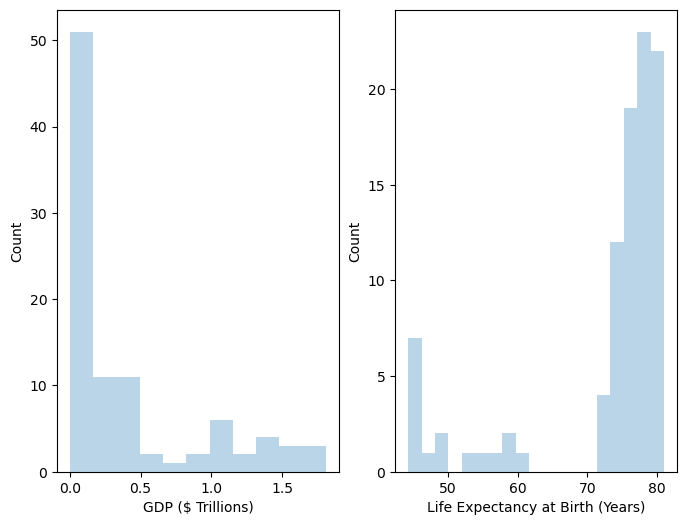

In [26]:
plt.figure(figsize = (8,6))
ax1 = plt.subplot(1, 2, 1)
sns.histplot(data= df, x= 'GDPT', edgecolor='none', alpha= 0.3)
plt.xlabel('GDP ($ Trillions)')

ax2 = plt.subplot(1, 2, 2)
sns.histplot(data= df, x= 'LEB', edgecolor='none', alpha= 0.3)
plt.xlabel('Life Expectancy at Birth (Years)')

plt.savefig('gpd_and_leb_histograms.png')

plt.show()
plt.close('all')


Now let's look at the mean values for those metrics across countries.<br>
We can see that the `GDP` values have a great variation accross countries, with the U.S. having a much higher value.<br>
In regards to `Life Expectancy`, the mean values are evenly distributed accross countries, with Zimbabwe having a lower value than the others.

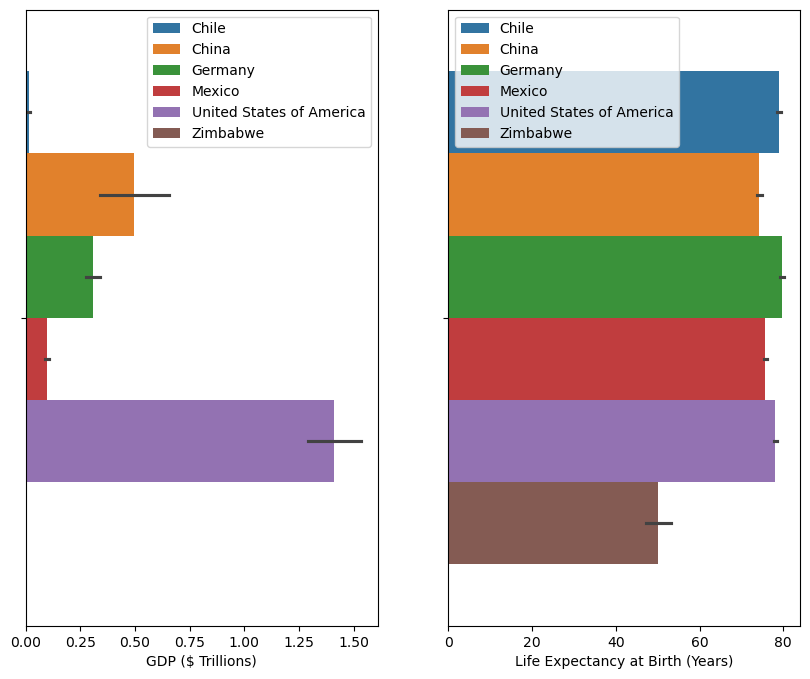

In [27]:
plt.figure(figsize = (10, 8))
ax1 = plt.subplot(1, 2, 1)
sns.barplot(
    data= df,
    x= 'GDPT',
    hue= 'Country',
)
plt.legend(loc= 'upper right')
plt.xlabel('GDP ($ Trillions)')

ax2 = plt.subplot(1, 2, 2)
sns.barplot(
    data= df,
    x= 'LEB',
    hue= 'Country',
)
plt.legend(loc= 'upper left')
plt.xlabel('Life Expectancy at Birth (Years)')


plt.savefig('gpd_and_leb_by_country.png')

plt.show()
plt.close('all')

Next let's look at the chart below, showing the evolution of `GDP` over the years across all countries.<br>
In contries such as the **U.S. and China** `GDPs` had significant growth over the years.<br>
Meanwhile in **Zimbabwe and Chile** it remained somewhat constant<br>
This could be a consequence of the scale being increased because of the huge gains in the U.S. and China.<br>
Finally, in **Germany and Mexico** `GDP` oscilates between growth and contraction along the years, the latest trend being of contraction.

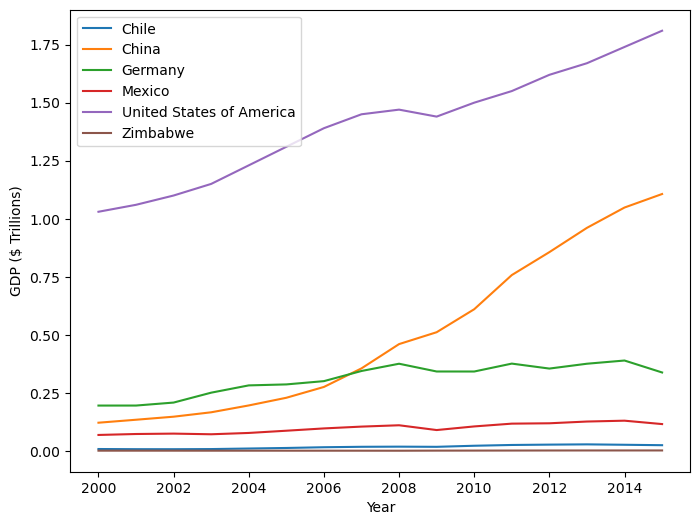

In [28]:
plt.figure(figsize = (8, 6))
plt.subplot(1, 1, 1)
ax = sns.lineplot(data= df, x= 'Year', y= 'GDPT', hue= 'Country')

# Extracting collor palette to reuse
country_names = [text.get_text() for text in ax.get_legend().get_texts()]#
line_colors = [line.get_color() for line in ax.get_lines()]
chart_palette_dict = dict(zip(country_names, line_colors))

plt.legend(loc= 'upper left')
plt.ylabel('GDP ($ Trillions)')

plt.savefig('gpd_over_time.png')

plt.show()
plt.close('all')

Let's now look at the indiviual plots for each country, to better grasp the individual growth.<br>
Looking at the individual growth, **China** indeed had the biggest growth of over 10 times its initial `GDP`.<br>
Meanwhile **Zimbabwe** has more than doubled its `GDP` in the same period. which is proportinally a greater growth than the **U.S.**.<br>
Other countries such as **Mexico, Germany and Chile** had similar behaviour, despite the latest trend.

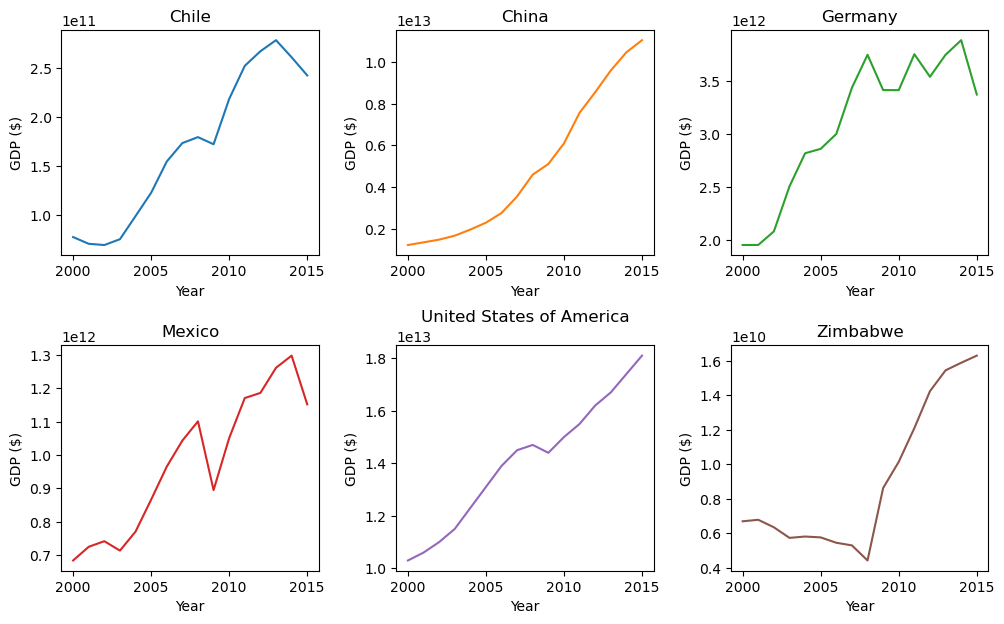

In [29]:
countries = df['Country'].unique()

plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
plt.tight_layout() # Or equivalently,  "plt.tight_layout()"
plt.subplots_adjust(wspace= 0.3, hspace= 0.4)

for i, country in enumerate(countries):
    plt.subplot(2, 3, i+1)
    country_df = df[df['Country'] == country]
    sns.lineplot(data= country_df, x= 'Year', y= 'GDP', color= chart_palette_dict[country])
    plt.title(country)
    plt.ylabel('GDP ($)')
    plt.xlabel('Year')


plt.savefig('gpd_over_time_by_country.png')

plt.show()
plt.close('all')

Next let's look at the chart below, portraying the `Life Expectancy at Birth` evolution in time accross each country.<br>
We can see that `Life Expectancy` values have been growing through the years accross all countries.<br>
Most notably **Zimbabwe** has had a sharper growth in comparison to the other countries. 

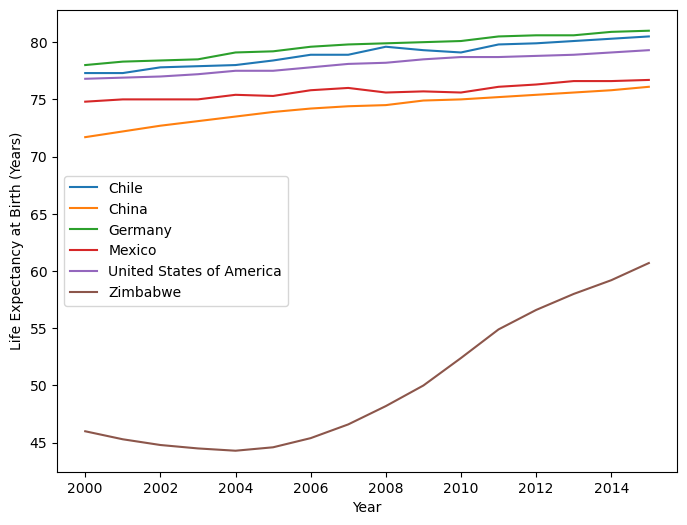

In [13]:
plt.figure(figsize = (8, 6))

plt.subplot(1, 1, 1)
sns.lineplot(data= df, x= 'Year', y= 'LEB', hue= 'Country')
plt.legend(loc= 'center left')
plt.ylabel('Life Expectancy at Birth (Years)')

plt.show()
plt.close('all')

Now looking at the charts below with the evolution of `Life Expectancy at Birth` throught the years isolated by country,<br>
we can see dips in the curver of **Chile** and **Mexico** in similar periods of time, from 2007 to 2011 approximately.


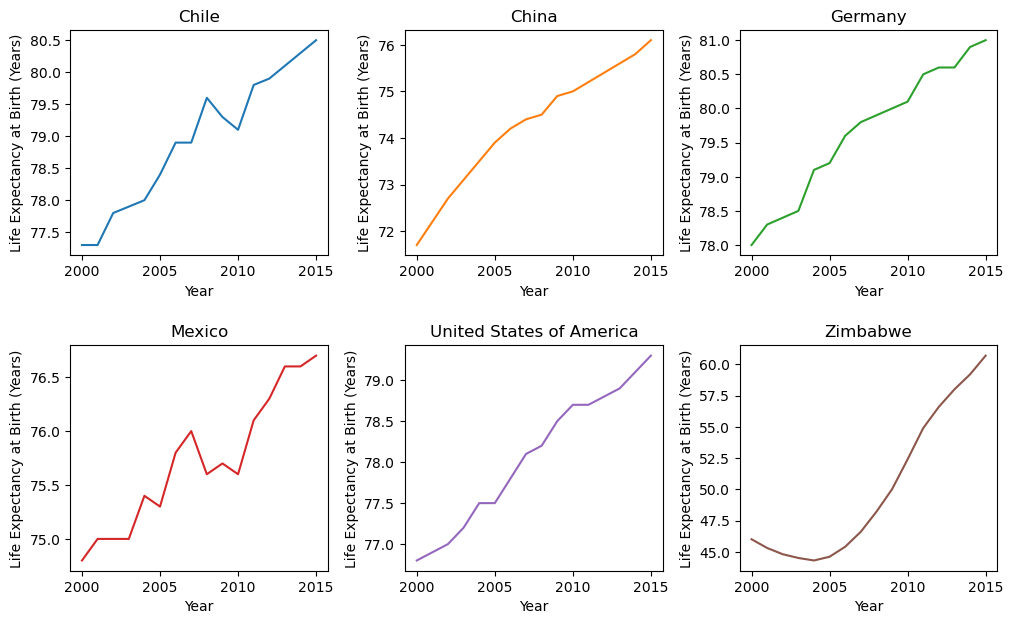

In [14]:
plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
plt.tight_layout() # Or equivalently,  "plt.tight_layout()"
plt.subplots_adjust(wspace= 0.3, hspace= 0.4)

for i, country in enumerate(countries):
    plt.subplot(2, 3, i+1)
    country_df = df[df['Country'] == country]
    sns.lineplot(data= country_df, x= 'Year', y= 'LEB', color= chart_palette_dict[country])
    plt.title(country)
    plt.ylabel('Life Expectancy at Birth (Years)')
    plt.xlabel('Year')

plt.show()
plt.close('all')

## Statistical Analysis

The following chart shows the correlation of `GDP` and `Life Expectancy at Birth` accross countries.<br>
Looking at all the countries plotted in the same graph, we can clearly see the clusters of values for each country.<br>
These clusters do indicate that there is a positive correlation between `Life Expectancy at Birth` and `GDP`.<br>
Let's make separate charts for each country to better see the correlation.

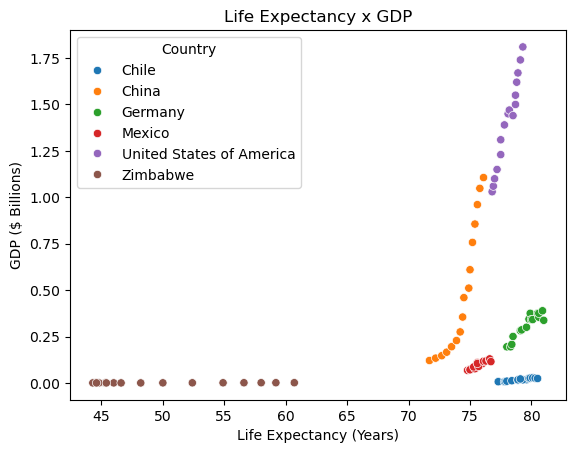

In [15]:
sns.scatterplot(data= df, x ='LEB', y= 'GDPT', hue= 'Country')
plt.title('Life Expectancy x GDP')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('GDP ($ Billions)')
plt.show()
plt.close('all')

Looking at the charts bellow we can more clearly see the positive correlation between `Life Expectancy at Birth` and `GDP`<br>
In most countries the relationship seems linear, except in **China** in which it appears logarithmic.

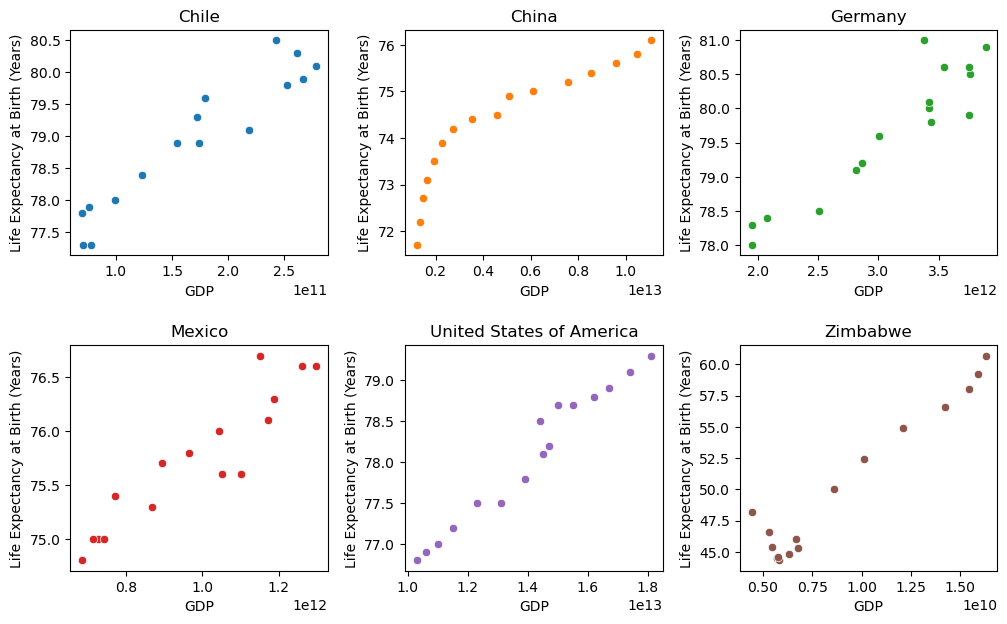

In [24]:
plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
plt.tight_layout()
plt.subplots_adjust(wspace= 0.3, hspace= 0.4)

for i, country in enumerate(countries):
    plt.subplot(2, 3, i+1)
    country_df = df[df['Country'] == country]
    sns.scatterplot(data= country_df, x= 'GDP', y= 'LEB', color= chart_palette_dict[country])
    plt.title(country)
    plt.ylabel('Life Expectancy at Birth (Years)')
    plt.xlabel('GDP')

plt.show()
plt.close('all')

## Conclusions
- Has `GDP` of countries increased during the years?
    - Yes, we can conclude that the `GDP` of the analyzed countries has increased over the years. Some at a way sharper rate than others.
- Has `Life Expectancy at Birth` of countries increased over the years?
    - Yes, `Life Expectancy at Birth` has increased accross all countries from 2000 to 2015, with some of them presenting variations through the years and some with sharpest growth than others.
- Is there correlation between `GDP` values and `Life Expectancy at Birth`?
    - Yes, we can see on the charts that there is a positive correlation between these two variables.